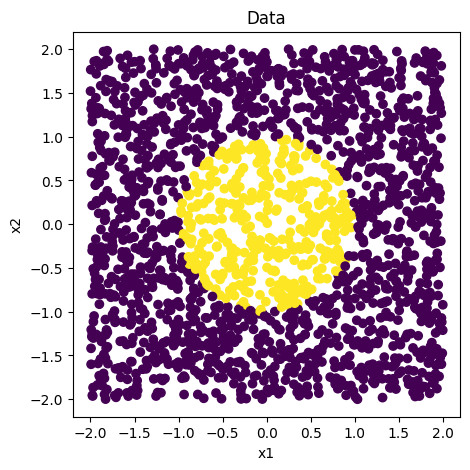

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Generate a complex dataset that causes overfitting
# ---------------------------------------------------------
def generate_hard_dataset(n_samples=2000, noise_dims=20, seed=0):
    np.random.seed(seed)

    # Core informative features (2D)
    X_core = np.random.uniform(-2, 2, size=(n_samples, 2))

    # True rule: circle boundary
    y = (X_core[:, 0]**2 + X_core[:, 1]**2 < 1.0).astype(int).reshape(-1, 1)

    # Add many irrelevant noise features
    X_noise = np.random.randn(n_samples, noise_dims)

    X = np.concatenate([X_core, X_noise], axis=1)

    return X, y


# Create dataset
X, y = generate_hard_dataset()
# ----- Plot 1: Logistic Regression -----
plt.figure(figsize=(5, 5))
#plt.contour(xx, yy, Z_lr, levels=[0.5])
plt.scatter(X[:, 0], X[:, 1], c=y.ravel())
plt.title("Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [6]:
# ---------------------------------------------------------
# 2. Train/Validation split
# ---------------------------------------------------------
idx = np.random.permutation(len(X))
X.shape

(2000, 22)

Epoch 30: Train Loss = 0.6576, Val Loss = 0.6567
Epoch 60: Train Loss = 0.6164, Val Loss = 0.6170
Epoch 90: Train Loss = 0.5836, Val Loss = 0.5853
Epoch 120: Train Loss = 0.5577, Val Loss = 0.5601
Epoch 150: Train Loss = 0.5374, Val Loss = 0.5404
Epoch 180: Train Loss = 0.5215, Val Loss = 0.5251
Epoch 210: Train Loss = 0.5093, Val Loss = 0.5134
Epoch 240: Train Loss = 0.4999, Val Loss = 0.5044
Epoch 270: Train Loss = 0.4927, Val Loss = 0.4977
Epoch 300: Train Loss = 0.4873, Val Loss = 0.4927
Epoch 330: Train Loss = 0.4832, Val Loss = 0.4892
Epoch 360: Train Loss = 0.4801, Val Loss = 0.4868
Epoch 390: Train Loss = 0.4776, Val Loss = 0.4852
Epoch 420: Train Loss = 0.4757, Val Loss = 0.4843
Epoch 450: Train Loss = 0.4741, Val Loss = 0.4838
Epoch 480: Train Loss = 0.4727, Val Loss = 0.4836
Epoch 510: Train Loss = 0.4715, Val Loss = 0.4836
Epoch 540: Train Loss = 0.4704, Val Loss = 0.4837
Epoch 570: Train Loss = 0.4695, Val Loss = 0.4839
Epoch 600: Train Loss = 0.4686, Val Loss = 0.4840
Epo

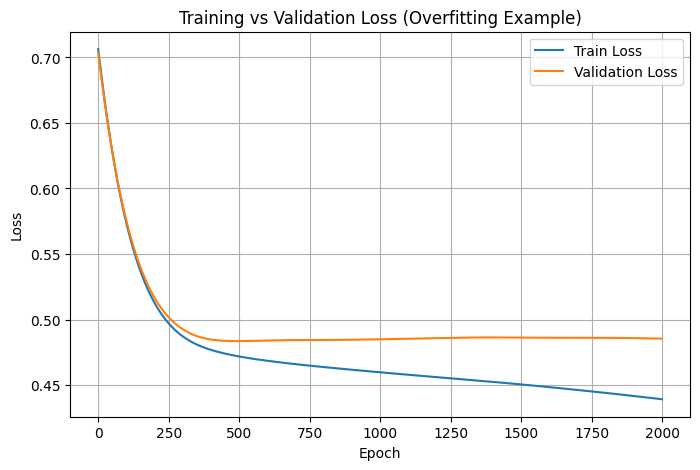

Done!


In [13]:
train_size = int(0.8 * len(X))
train_idx, val_idx = idx[:train_size], idx[train_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val     = X[val_idx], y[val_idx]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32)

# ---------------------------------------------------------
# 3. Multi-Layer ANN (intentionally flexible → overfits)
# ---------------------------------------------------------
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.Sigmoid(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(0)
model = MLP(input_dim=X_train.shape[1])

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ---------------------------------------------------------
# 4. Training loop with validation
# ---------------------------------------------------------
epochs = 2000
train_losses = []
val_losses = []

for epoch in range(epochs):
    # ----- Training -----
    model.train()
    optimizer.zero_grad()

    pred_train = model(X_train_t)
    train_loss = criterion(pred_train, y_train_t)
    train_loss.backward()
    optimizer.step()

    # ----- Validation -----
    model.eval()
    with torch.no_grad():
        pred_val = model(X_val_t)
        val_loss = criterion(pred_val, y_val_t)

    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1}: Train Loss = {train_loss.item():.4f}, Val Loss = {val_loss.item():.4f}")

# ---------------------------------------------------------
# 5. Plot train vs validation loss
# ---------------------------------------------------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Overfitting Example)")
plt.legend()
plt.grid(True)
plt.show()

print("Done!")